# 3. Machine Learning for Classification

We'll use logistic regression to predict churn


## 3.1 Churn prediction project

* Dataset: https://www.kaggle.com/blastchar/telco-customer-churn
* https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv


## 3.2 Data preparation

* Download the data, read it with pandas
* Look at the data
* Make column names and values look uniform
* Check if all the columns read correctly
* Check if the churn variable needs any preparation

In [109]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [111]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-03-churn-prediction/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [77]:
df = pd.read_csv(data)
df.to_csv("data-week-3.csv", index=False)

In [78]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [79]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [80]:
df.head().T

,0,1,2,3,4
customerid,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
seniorcitizen,0,0,0,0,0
partner,Yes,No,No,No,No
dependents,No,No,No,No,No
tenure,1,34,2,45,2
phoneservice,No,Yes,Yes,No,Yes
multiplelines,No phone service,No,No,No phone service,No
internetservice,DSL,DSL,DSL,DSL,Fiber optic
onlinesecurity,No,Yes,Yes,Yes,No


In [81]:
tc = pd.to_numeric(df.totalcharges, errors='coerce')

In [82]:
df.totalcharges = pd.to_numeric(df.totalcharges, errors='coerce')

In [83]:
df.totalcharges = df.totalcharges.fillna(0)

In [84]:
df.churn.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: churn, dtype: str

In [85]:
df.churn = (df.churn == 'yes').astype(int)

## 3.3 Setting up the validation framework

* Perform the train/validation/test split with Scikit-Learn

In [86]:
from sklearn.model_selection import train_test_split

In [87]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [88]:
len(df_train), len(df_val), len(df_test)

(4225, 1409, 1409)

In [89]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [90]:
y_train = df_train.churn.values
y_val = df_val.churn.values
y_test = df_test.churn.values

del df_train['churn']
del df_val['churn']
del df_test['churn']

## 3.4 EDA

* Check missing values
* Look at the target variable (churn)
* Look at numerical and categorical variables

In [91]:
df_full_train = df_full_train.reset_index(drop=True)

In [92]:
df_full_train.isnull().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [93]:
df_full_train.churn.value_counts(normalize=True)

churn
0    1.0
Name: proportion, dtype: float64

In [94]:
df_full_train.churn.mean()

np.float64(0.0)

In [95]:
numerical = ['tenure', 'monthlycharges', 'totalcharges']

In [96]:
categorical = [
    'gender',
    'seniorcitizen',
    'partner',
    'dependents',
    'phoneservice',
    'multiplelines',
    'internetservice',
    'onlinesecurity',
    'onlinebackup',
    'deviceprotection',
    'techsupport',
    'streamingtv',
    'streamingmovies',
    'contract',
    'paperlessbilling',
    'paymentmethod',
]

In [97]:
df_full_train[categorical].nunique()

gender              2
seniorcitizen       2
partner             2
dependents          2
phoneservice        2
multiplelines       3
internetservice     3
onlinesecurity      3
onlinebackup        3
deviceprotection    3
techsupport         3
streamingtv         3
streamingmovies     3
contract            3
paperlessbilling    2
paymentmethod       4
dtype: int64

## 3.5 Feature importance: Churn rate and risk ratio

Feature importance analysis (part of EDA) - identifying which features affect our target variable

* Churn rate
* Risk ratio
* Mutual information - later

#### Churn rate

In [98]:
df_full_train.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,5442-PPTJY,Male,0,Yes,Yes,12,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.70,258.35,0
1,6261-RCVNS,Female,0,No,No,42,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,One year,No,Credit card (automatic),73.90,3160.55,0
2,2176-OSJUV,Male,0,Yes,No,71,Yes,Yes,DSL,Yes,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),65.15,4681.75,0
3,6161-ERDGD,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,No,Electronic check,85.45,6300.85,0
4,2364-UFROM,Male,0,No,No,30,Yes,No,DSL,Yes,...,No,Yes,Yes,No,One year,No,Electronic check,70.40,2044.75,0


In [99]:
churn_female = df_full_train[df_full_train.gender == 'female'].churn.mean()
churn_female

nan

In [100]:
churn_male = df_full_train[df_full_train.gender == 'male'].churn.mean()
churn_male

nan

In [101]:
global_churn = df_full_train.churn.mean()
global_churn

np.float64(0.0)

In [102]:
global_churn - churn_female

np.float64(nan)

In [103]:
global_churn - churn_male

np.float64(nan)

In [104]:
df_full_train.partner.value_counts()

partner
No     2932
Yes    2702
Name: count, dtype: int64

In [105]:
churn_partner = df_full_train[df_full_train.partner == 'yes'].churn.mean()
churn_partner

nan

In [106]:
global_churn - churn_partner

np.float64(nan)

In [107]:
churn_no_partner = df_full_train[df_full_train.partner == 'no'].churn.mean()
churn_no_partner

nan

In [113]:
global_churn - churn_no_partner

np.float64(nan)

np.float64(nan)

#### Risk ratio

In [115]:
churn_no_partner / global_churn

np.float64(nan)

np.float64(nan)

In [117]:
churn_partner / global_churn

np.float64(nan)

np.float64(nan)

```
SELECT
    gender,
    AVG(churn),
    AVG(churn) - global_churn AS diff,
    AVG(churn) / global_churn AS risk
FROM
    data
GROUP BY
    gender;
```

In [119]:
from IPython.display import display

In [121]:
for c in categorical:
    print(c)
    df_group = df_full_train.groupby(c).churn.agg(['mean', 'count'])
    df_group['diff'] = df_group['mean'] - global_churn
    df_group['risk'] = df_group['mean'] / global_churn
    display(df_group)
    print()
    print()

gender


,mean,count,diff,risk
gender,,,,
Female,0.0,2796,0.0,NaN
Male,0.0,2838,0.0,NaN




seniorcitizen


,mean,count,diff,risk
seniorcitizen,,,,
0,0.0,4722,0.0,NaN
1,0.0,912,0.0,NaN




partner


...

,mean,count,diff,risk
contract,,,,
Month-to-month,0.0,3104,0.0,NaN
One year,0.0,1186,0.0,NaN
Two year,0.0,1344,0.0,NaN




paperlessbilling


,mean,count,diff,risk
paperlessbilling,,,,
No,0.0,2313,0.0,NaN
Yes,0.0,3321,0.0,NaN




paymentmethod


,mean,count,diff,risk
paymentmethod,,,,
Bank transfer (automatic),0.0,1219,0.0,NaN
Credit card (automatic),0.0,1217,0.0,NaN
Electronic check,0.0,1893,0.0,NaN
Mailed check,0.0,1305,0.0,NaN


## 3.6 Feature importance: Mutual information

Mutual information - concept from information theory, it tells us how much 
we can learn about one variable if we know the value of another

* https://en.wikipedia.org/wiki/Mutual_information

In [123]:
from sklearn.metrics import mutual_info_score

In [125]:
mutual_info_score(df_full_train.churn, df_full_train.contract)

0.0

0.0

In [127]:
mutual_info_score(df_full_train.gender, df_full_train.churn)

0.0

0.0

In [129]:
mutual_info_score(df_full_train.contract, df_full_train.churn)

0.0

0.0

In [131]:
mutual_info_score(df_full_train.partner, df_full_train.churn)

0.0

0.0

In [133]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.churn)

In [135]:
mi = df_full_train[categorical].apply(mutual_info_churn_score)
mi.sort_values(ascending=False)

gender              0.0
seniorcitizen       0.0
partner             0.0
dependents          0.0
phoneservice        0.0
multiplelines       0.0
internetservice     0.0
onlinesecurity      0.0
onlinebackup        0.0
deviceprotection    0.0
techsupport         0.0
streamingtv         0.0
streamingmovies     0.0
contract            0.0
paperlessbilling    0.0
paymentmethod       0.0
dtype: float64

gender              0.0
seniorcitizen       0.0
partner             0.0
dependents          0.0
phoneservice        0.0
multiplelines       0.0
internetservice     0.0
onlinesecurity      0.0
onlinebackup        0.0
deviceprotection    0.0
techsupport         0.0
streamingtv         0.0
streamingmovies     0.0
contract            0.0
paperlessbilling    0.0
paymentmethod       0.0
dtype: float64

## 3.7 Feature importance: Correlation

How about numerical columns?

* Correlation coefficient - https://en.wikipedia.org/wiki/Pearson_correlation_coefficient

In [137]:
df_full_train.tenure.max()

np.int64(72)

np.int64(72)

In [139]:
df_full_train[numerical].corrwith(df_full_train.churn).abs()

C:\Users\Acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


tenure           NaN
monthlycharges   NaN
totalcharges     NaN
dtype: float64

C:\Users\Acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Acer\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


tenure           NaN
monthlycharges   NaN
totalcharges     NaN
dtype: float64

In [141]:
df_full_train[df_full_train.tenure <= 2].churn.mean()

np.float64(0.0)

np.float64(0.0)

In [143]:
df_full_train[(df_full_train.tenure > 2) & (df_full_train.tenure <= 12)].churn.mean()

np.float64(0.0)

np.float64(0.0)

In [145]:
df_full_train[df_full_train.tenure > 12].churn.mean()

np.float64(0.0)

np.float64(0.0)

In [147]:
df_full_train[df_full_train.monthlycharges <= 20].churn.mean()

np.float64(0.0)

np.float64(0.0)

In [149]:
df_full_train[(df_full_train.monthlycharges > 20) & (df_full_train.monthlycharges <= 50)].churn.mean()

np.float64(0.0)

np.float64(0.0)

In [151]:
df_full_train[df_full_train.monthlycharges > 50].churn.mean()

np.float64(0.0)

np.float64(0.0)

## 3.8 One-hot encoding

* Use Scikit-Learn to encode categorical features

In [153]:
from sklearn.feature_extraction import DictVectorizer

In [155]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

## 3.9 Logistic regression

* Binary classification
* Linear vs logistic regression

In [157]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [159]:
z = np.linspace(-7, 7, 51)

In [161]:
sigmoid(10000)

np.float64(1.0)

np.float64(1.0)

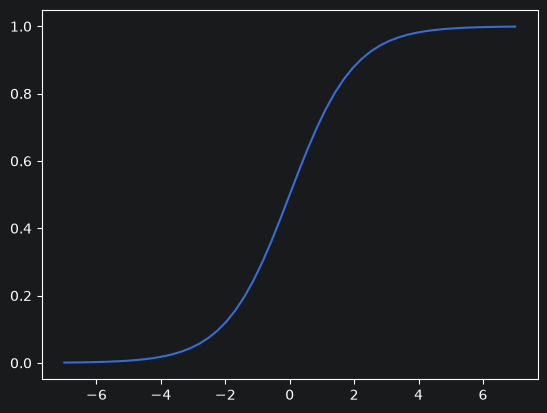

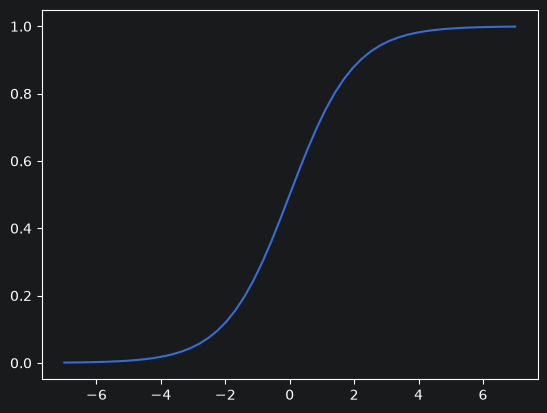

In [163]:
plt.plot(z, sigmoid(z))

In [165]:
def linear_regression(xi):
    result = w0
    
    for j in range(len(w)):
        result = result + xi[j] * w[j]
        
    return result

In [167]:
def logistic_regression(xi):
    score = w0
    
    for j in range(len(w)):
        score = score + xi[j] * w[j]
        
    result = sigmoid(score)
    return result

## 3.10 Training logistic regression with Scikit-Learn

* Train a model with Scikit-Learn
* Apply it to the validation dataset
* Calculate the accuracy

In [164]:
from sklearn.linear_model import LogisticRegression

In [166]:
import numpy as np

print("Unique classes in y_train:", np.unique(y_train))
print("Counts per class:\n", pd.Series(y_train).value_counts())

Unique classes in y_train: [0]
Counts per class:
 0    4225
Name: count, dtype: int64


In [168]:
model = LogisticRegression(solver='lbfgs')
# solver='lbfgs' is the default solver in newer version of sklearn
# for older versions, you need to specify it explicitly
model.fit(X_train, y_train)

ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: np.int64(0)

In [ ]:
model.intercept_[0]

In [ ]:
model.coef_[0].round(3)

In [ ]:
y_pred = model.predict_proba(X_val)[:, 1]

In [ ]:
churn_decision = (y_pred >= 0.5)

In [ ]:
(y_val == churn_decision).mean()

In [ ]:
df_pred = pd.DataFrame()
df_pred['probability'] = y_pred
df_pred['prediction'] = churn_decision.astype(int)
df_pred['actual'] = y_val

In [ ]:
df_pred['correct'] = df_pred.prediction == df_pred.actual

In [ ]:
df_pred.correct.mean()

In [ ]:
churn_decision.astype(int)

## 3.11 Model interpretation

* Look at the coefficients
* Train a smaller model with fewer features

In [ ]:
a = [1, 2, 3, 4]
b = 'abcd'

In [ ]:
dict(zip(a, b))

In [ ]:
dict(zip(dv.get_feature_names_out(), model.coef_[0].round(3)))

In [ ]:
small = ['contract', 'tenure', 'monthlycharges']

In [ ]:
df_train[small].iloc[:10].to_dict(orient='records')

In [ ]:
dicts_train_small = df_train[small].to_dict(orient='records')
dicts_val_small = df_val[small].to_dict(orient='records')

In [ ]:
dv_small = DictVectorizer(sparse=False)
dv_small.fit(dicts_train_small)

In [ ]:
dv_small.get_feature_names_out()

In [ ]:
X_train_small = dv_small.transform(dicts_train_small)

In [ ]:
model_small = LogisticRegression(solver='lbfgs')
model_small.fit(X_train_small, y_train)

In [ ]:
w0 = model_small.intercept_[0]
w0

In [ ]:
w = model_small.coef_[0]
w.round(3)

In [ ]:
dict(zip(dv_small.get_feature_names_out(), w.round(3)))

In [ ]:
-2.47 + (-0.949) + 30 * 0.027 + 24 * (-0.036)

In [ ]:
sigmoid(_)

## 3.12 Using the model

In [ ]:
dicts_full_train = df_full_train[categorical + numerical].to_dict(orient='records')

In [ ]:
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

In [ ]:
y_full_train = df_full_train.churn.values

In [ ]:
model = LogisticRegression(solver='lbfgs')
model.fit(X_full_train, y_full_train)

In [ ]:
dicts_test = df_test[categorical + numerical].to_dict(orient='records')

In [ ]:
X_test = dv.transform(dicts_test)

In [ ]:
y_pred = model.predict_proba(X_test)[:, 1]

In [ ]:
churn_decision = (y_pred >= 0.5)

In [ ]:
(churn_decision == y_test).mean()

In [ ]:
y_test

In [ ]:
customer = dicts_test[-1]
customer

In [ ]:
X_small = dv.transform([customer])

In [ ]:
model.predict_proba(X_small)[0, 1]

In [ ]:
y_test[-1]

## 3.13 Summary

* Feature importance - risk, mutual information, correlation
* One-hot encoding can be implemented with `DictVectorizer`
* Logistic regression - linear model like linear regression
* Output of log reg - probability
* Interpretation of weights is similar to linear regression

## 3.14 Explore more

More things

* Try to exclude least useful features


Use scikit-learn in project of last week

* Re-implement train/val/test split using scikit-learn in the project from the last week
* Also, instead of our own linear regression, use `LinearRegression` (not regularized) and `RidgeRegression` (regularized). Find the best regularization parameter for Ridge

Other projects

* Lead scoring - https://www.kaggle.com/ashydv/leads-dataset
* Default prediction - https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients

